# Projeto - Insuficiencia Cardiaca

## Informações do conjunto de dados

1 - Age: idade do paciente [anos]\
2 - Sex: sexo do paciente [M: Masculino, F: Feminino]\
3 - ChestPainType: tipo de dor torácica [TA: Angina típica, ATA: Angina atípica, NAP: Dor não anginosa, ASY: Assintomática]\
4 - ResgingBP: pressão arterial em repouso [mm Hg]\
5- Cholesterol: colesterol sérico [mm/dl]\
6- FastingBS: glicemia em jejum [1: se BS em jejum > 120 mg/dl, 0: caso contrário]\
7 - ResgingECG: resultados do eletrocardiograma em repouso [Normal: Normal, ST: com anormalidade das ondas ST-T (inversões das ondas T e/ou elevação ou depressão de ST > 0,05 mV), HVE: mostrando hipertrofia ventricular esquerda provável ou definitiva pelos critérios de testes]\
8 - MaxHR: frequência cardíaca máxima alcançada [valor numérico entre 60 e 202]\
9 - ExercícioAngina: angina induzida por exercício [Y: Sim, N: Não]\
10 - Oldpeak: oldpeak = ST [Valor numérico medido na depressão]\
11 - ST_Slope: a inclinação do segmento ST do pico do exercício [Up: subida, Flat: flat, Down: downsloping]\
12 - HeartDisease: classe de saída [1: doença cardíaca, 0: Normal]

In [2]:
# Importando os pacotes que serão utilizados

import warnings
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import time

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from imblearn import under_sampling, over_sampling
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, accuracy_score

pd.set_option('display.max_columns', None) # Exibir todas as colunas do DataFrame sem cortes no meio
pd.set_option('display.max_rows', None) # Exibir todas as linhas do DataFrame sem cortes no meio
warnings.filterwarnings("ignore")  #ignora avisos do python
pd.options.display.float_format = '{:.2f}'.format  # Formata os números decimais para exibir apenas duas casas decimais


In [3]:
# Carregando o arquivo CSV

df_original = pd.read_csv('heart.csv')

In [4]:
# Verificando as primeiras linhas do DataFrame

df_original.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.00,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.00,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.00,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.50,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.00,Up,0


In [5]:
# Verificando as dimensões do arquivo.

df_original.shape

(918, 12)

In [6]:
# Verificando informações do arquivo

df_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [7]:
# Verificando se há valores nulos (dados missing)

df_original.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

- Vamos percorrer por cada coluna descobrindo quantos valores únicos existem. O objetivo é a avaliar a cardianalidade dos dados presentes

In [ ]:
# Descobrindo os valores únicos de cada coluna

df_original.nunique()

Age                50
Sex                 2
ChestPainType       4
RestingBP          67
Cholesterol       222
FastingBS           2
RestingECG          3
MaxHR             119
ExerciseAngina      2
Oldpeak            53
ST_Slope            3
HeartDisease        2
dtype: int64

- **Describe** para uma visualização estatística rápida

In [9]:
# Visualizando algumas medidas estatisticas.

df_original.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.00,918.00,918.00,918.00,918.00,918.00,918.00
mean,53.51,132.40,198.80,0.23,136.81,0.89,0.55
std,9.43,18.51,109.38,0.42,25.46,1.07,0.50
min,28.00,0.00,0.00,0.00,60.00,-2.60,0.00
25%,47.00,120.00,173.25,0.00,120.00,0.00,0.00
50%,54.00,130.00,223.00,0.00,138.00,0.60,1.00
75%,60.00,140.00,267.00,0.00,156.00,1.50,1.00
max,77.00,200.00,603.00,1.00,202.00,6.20,1.00


In [10]:
# Quantidade de observações por Sexo
df_original.groupby(['Sex']).size()

Sex
F    193
M    725
dtype: int64

- Gráfico rápido de barras

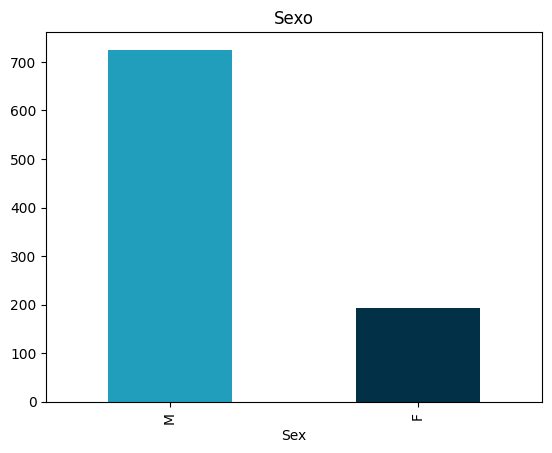

In [11]:
# Visualizando através do gráfico
df_original.Sex.value_counts().plot(kind='bar', title='Sexo',color = ['#219ebc', '#023047']);

In [12]:
# Quantidade de observações por Tipo de Dor Toraxica
df_original.groupby(['ChestPainType']).size()

ChestPainType
ASY    496
ATA    173
NAP    203
TA      46
dtype: int64

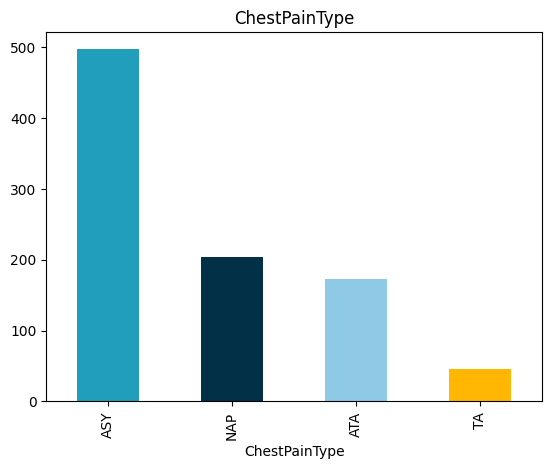

In [13]:
# Visualizando através do gráfico
df_original.ChestPainType.value_counts().plot(kind='bar', title='ChestPainType',color = ['#219ebc', '#023047', '#8ecae6', '#ffb703']);

In [14]:
# Quantidade de observações por Glicemia em Jejum
df_original.groupby(['FastingBS']).size()

FastingBS
0    704
1    214
dtype: int64

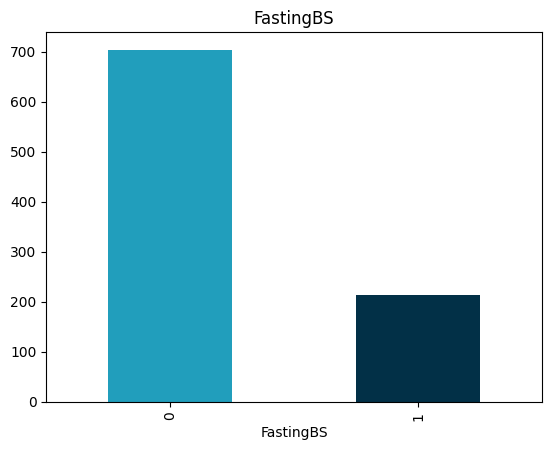

In [15]:
# Visualizando através do gráfico
df_original.FastingBS.value_counts().plot(kind='bar', title='FastingBS',color = ['#219ebc', '#023047']);

In [16]:
# Quantidade de observações por Tipo de Dor Toraxica
df_original.groupby(['RestingECG']).size()

RestingECG
LVH       188
Normal    552
ST        178
dtype: int64

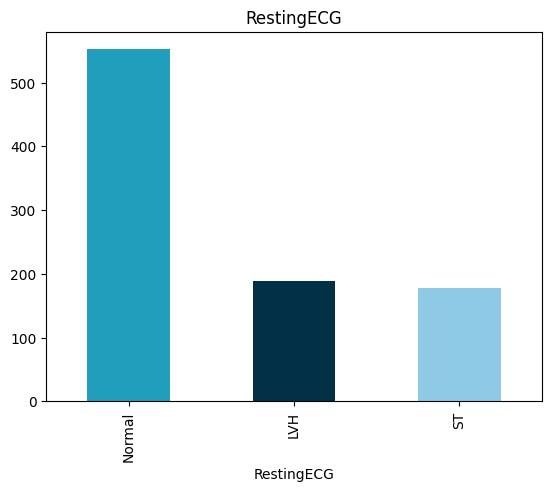

In [17]:
# Visualizando através do gráfico
df_original.RestingECG.value_counts().plot(kind='bar', title='RestingECG',color = ['#219ebc', '#023047', '#8ecae6']);

In [18]:
# Quantidade de observações por Angina Induzida
df_original.groupby(['ExerciseAngina']).size()

ExerciseAngina
N    547
Y    371
dtype: int64

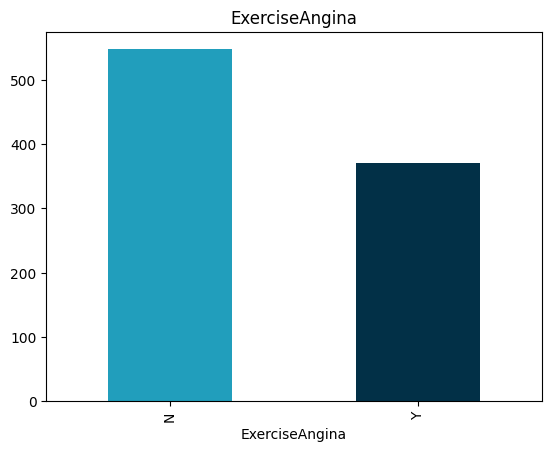

In [19]:
# Visualizando através do gráfico
df_original.ExerciseAngina.value_counts().plot(kind='bar', title='ExerciseAngina',color = ['#219ebc', '#023047']);

In [20]:
# Quantidade de observações Inclinação Pico Exercicio
df_original.groupby(['ST_Slope']).size().sort_values(ascending=False)

ST_Slope
Flat    460
Up      395
Down     63
dtype: int64

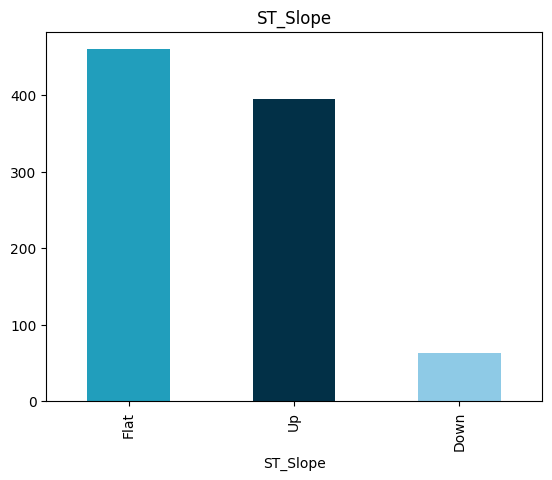

In [21]:
# Visualizando através do gráfico
df_original.ST_Slope.value_counts().plot(kind='bar', title='ST_Slope',color = ['#219ebc', '#023047', '#8ecae6']);

In [ ]:
# Quantidade de observações de Doença Cardiaca (Variagel TARGET)
df_original.groupby(['HeartDisease']).size()

HeartDisease
0    410
1    508
dtype: int64

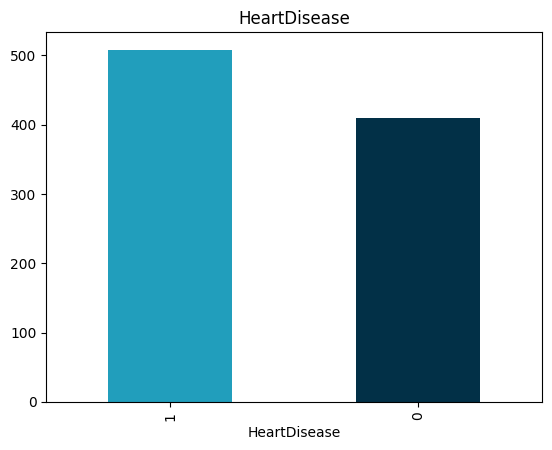

In [23]:
df_original.HeartDisease.value_counts().plot(kind='bar', title='HeartDisease',color = ['#219ebc', '#023047']);

# Analisando variaveis categóricas em relação a variável alvo




In [24]:
# Formatando o tamanho do plot
plt.rcParams["figure.figsize"] = [8.00, 4.00]
plt.rcParams["figure.autolayout"] = True  #ajuste automático do layout para evitar sobreposição de elementos

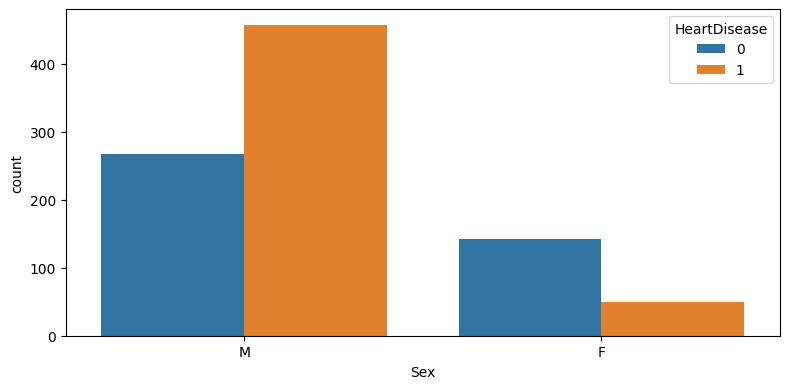

In [25]:
# Visualizando a Variável Sex x HeartDisease

sns.countplot(data = df_original, x = "Sex", hue = "HeartDisease")
plt.show()

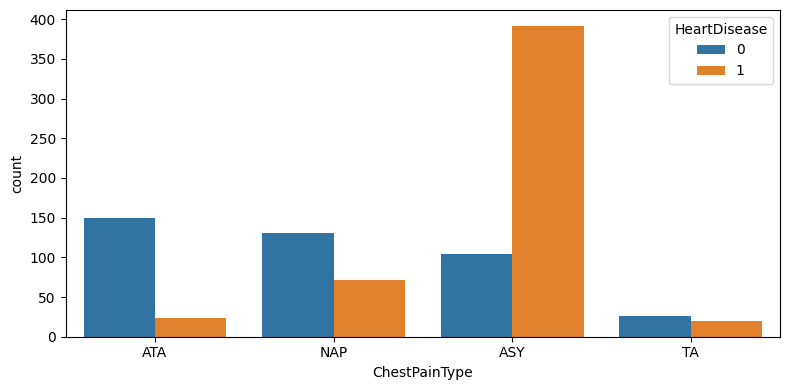

In [26]:
# Visualizando a Variável ChestPainType x HeartDisease

sns.countplot(data = df_original, x = "ChestPainType", hue = "HeartDisease")
plt.show()

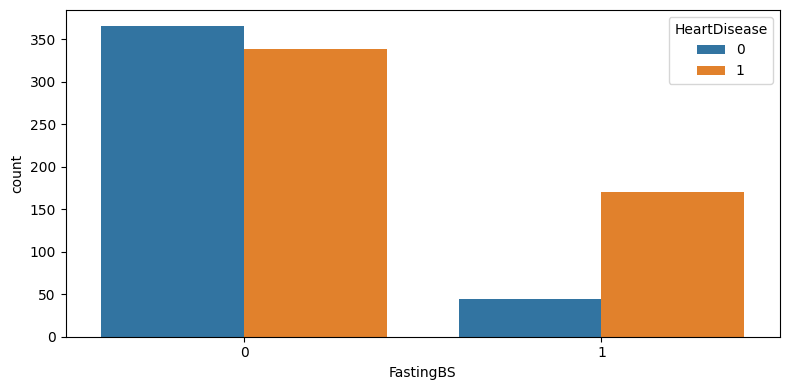

In [27]:
# Visualizando a Variável FastingBS x HeartDisease

sns.countplot(data = df_original, x = "FastingBS", hue = "HeartDisease")
plt.show()

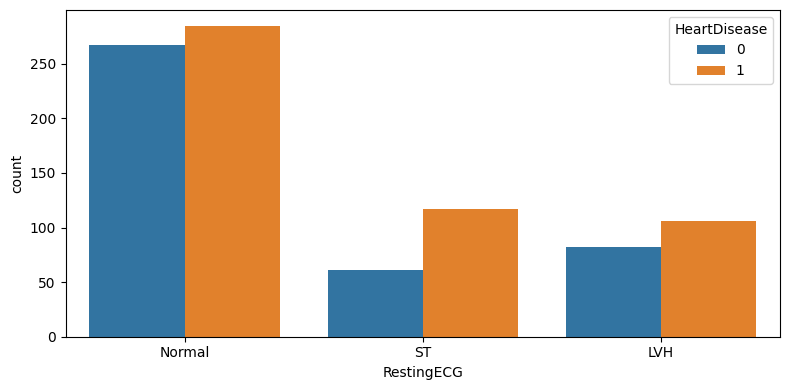

In [28]:
# Visualizando a Variável RestingECG x HeartDisease

sns.countplot(data = df_original, x = "RestingECG", hue = "HeartDisease")
plt.show()

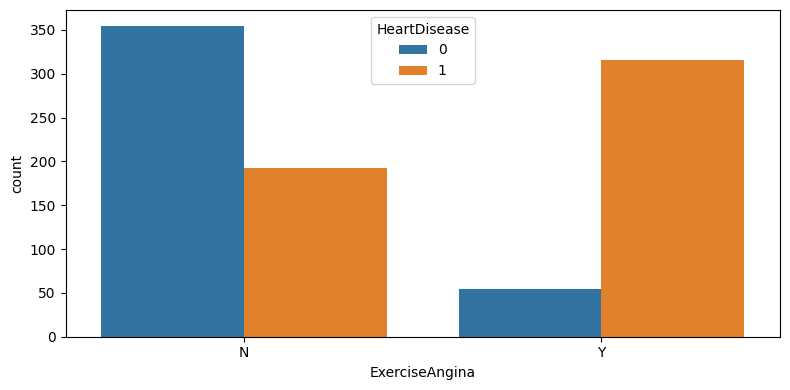

In [29]:
# Visualizando a Variável ExerciseAngina x HeartDisease

sns.countplot(data = df_original, x = "ExerciseAngina", hue = "HeartDisease")
plt.show()

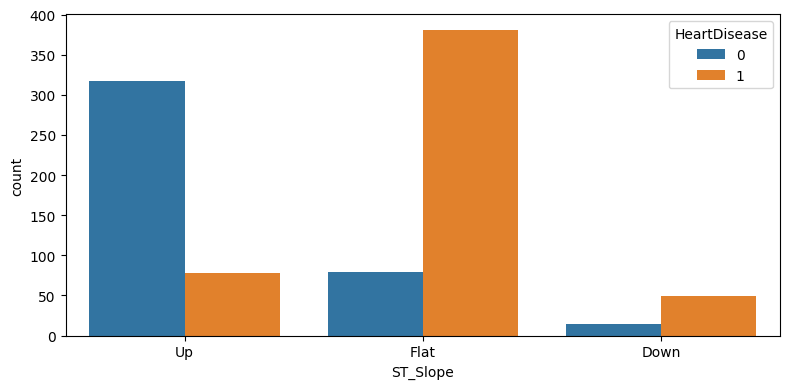

In [30]:
# Visualizando a Variável ST_Slope x HeartDisease

sns.countplot(data = df_original, x = "ST_Slope", hue = "HeartDisease")
plt.show()

- Vamos converter as colunas do tipo "object" para "category" e por quê??   
   - Ao converter para "category" ajuda no consumo de memória, além de facilitar na velocidade de processamento   
   dos dados ajuda também nos modelos de machine learning

In [31]:
# Convertendo as variaveis do tipo Object para Category

obj_cols = df_original.select_dtypes(include='object').columns

df_original[obj_cols] = df_original[obj_cols].astype('category')

In [32]:
df_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   Age             918 non-null    int64   
 1   Sex             918 non-null    category
 2   ChestPainType   918 non-null    category
 3   RestingBP       918 non-null    int64   
 4   Cholesterol     918 non-null    int64   
 5   FastingBS       918 non-null    int64   
 6   RestingECG      918 non-null    category
 7   MaxHR           918 non-null    int64   
 8   ExerciseAngina  918 non-null    category
 9   Oldpeak         918 non-null    float64 
 10  ST_Slope        918 non-null    category
 11  HeartDisease    918 non-null    int64   
dtypes: category(5), float64(1), int64(6)
memory usage: 55.5 KB


In [ ]:
# Criando uma lista para armazenar apenas as variáveis numéricas do DataFrame

variaveis_numericas = []
for i in df_original.columns[0:11].tolist():
        if df_original.dtypes[i] == 'int64' or df_original.dtypes[i] == 'float64':                        
            variaveis_numericas.append(i)   

In [34]:
variaveis_numericas

['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']

In [ ]:
# Valor total de variáveis numéricas

len(variaveis_numericas)

6

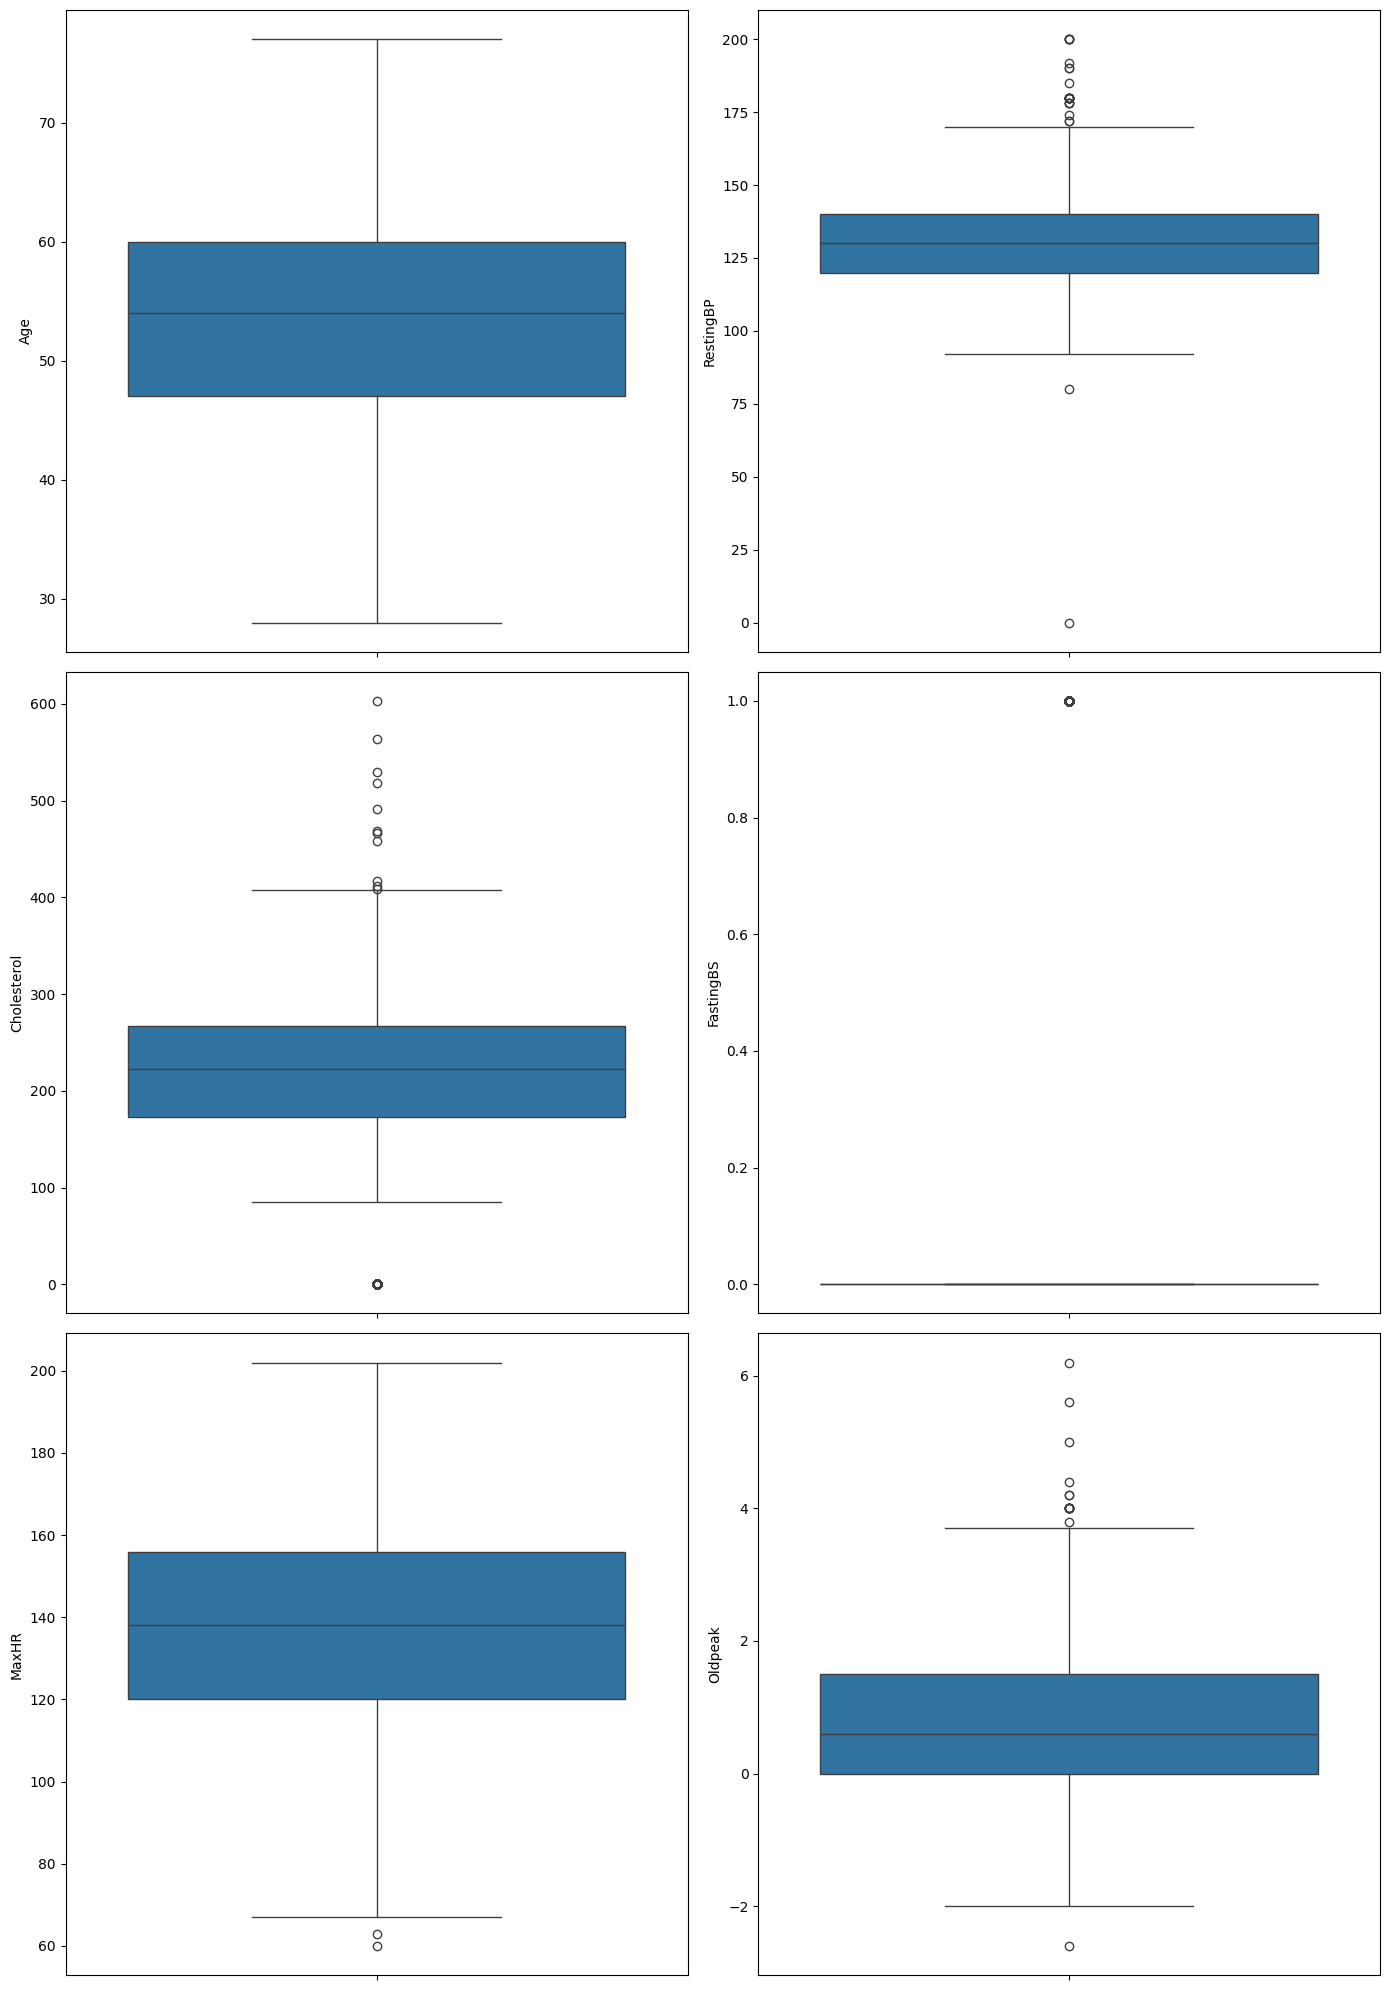

In [36]:
#Podemos observar nos boxplots abaixo que as variáveis númericas apresentam uma grande quantidade de "possíveis" outliers
#Precisamos avaliar cada uma dessas variaveis dentro do contexto dos dados para saber se realmente iremos trata-las como outlier


# A LÓGICA ABAIXO É O SEGUINTE:
# criamos um loop para percorrer as variáveis númericas, e para cada variável, criamos um boxplot utilizando a biblioteca seaborn.
# O resultado é um grid de boxplots, onde cada boxplot representa a distribuição de uma variável numérica.


plt.rcParams["figure.figsize"] = [14.00, 20.00]
plt.rcParams["figure.autolayout"] = True
f, axes = plt.subplots(3, 2) #3 linhas e 2 colunas

linha = 0
coluna = 0
for i in variaveis_numericas:
    sns.boxplot(data = df_original, y=i, ax=axes[linha][coluna])
    coluna += 1    #coluna é 0 e começa o contador com 1
    if coluna == 2:  #quando for 2 colunas na mesma linha e desce para a próxima linha
        linha += 1
        coluna = 0            

plt.show()

- Perceba abaixo que os dados estão altamente desequilibrados e desproporcionais

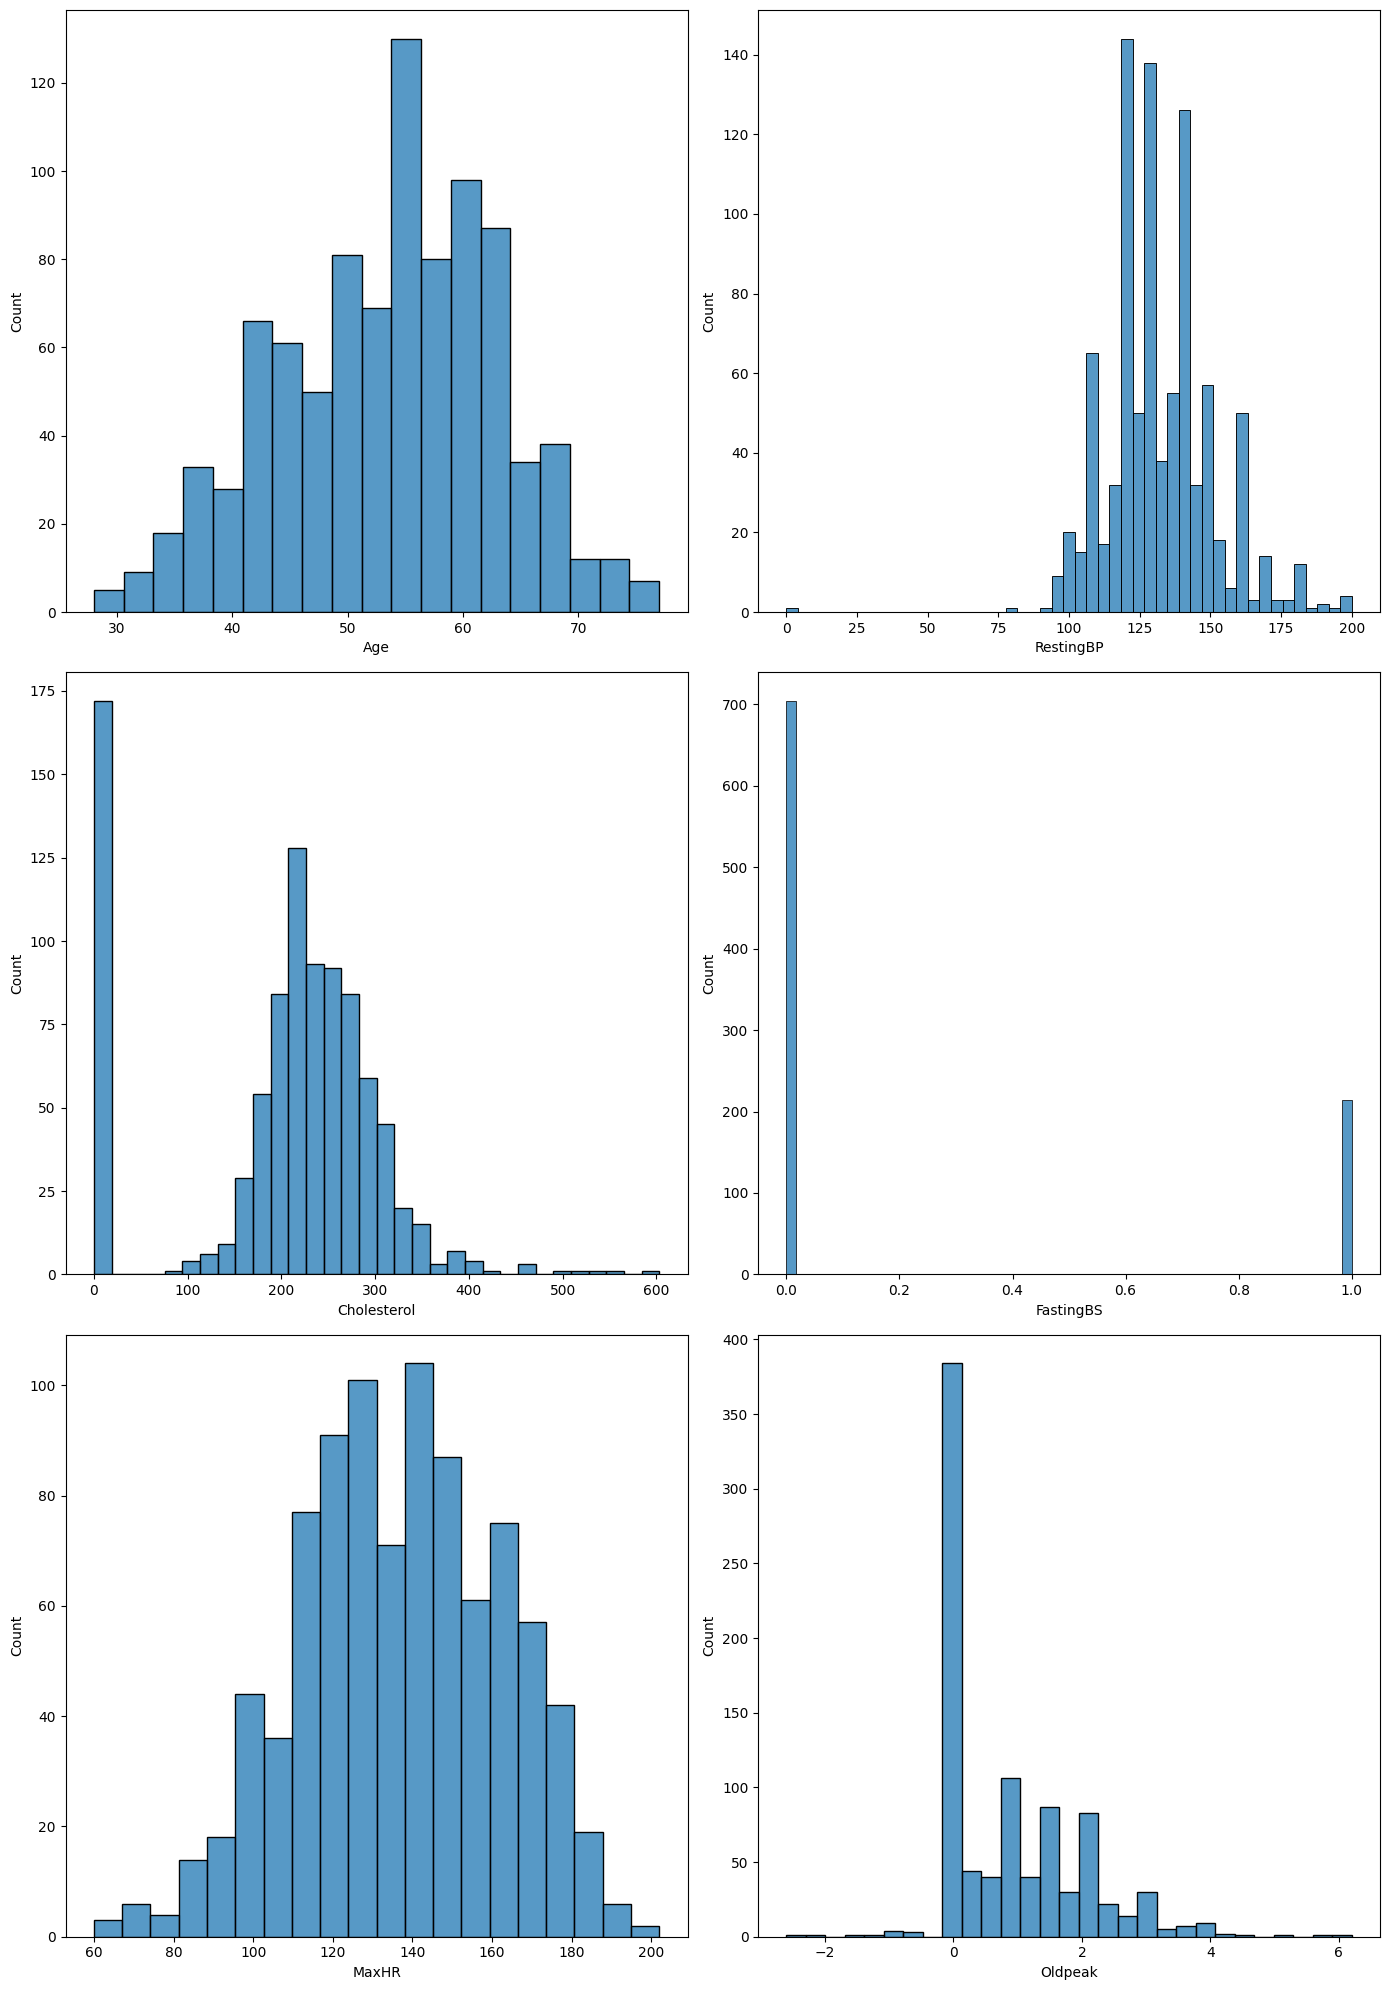

In [ ]:
plt.rcParams["figure.figsize"] = [14.00, 20.00]
plt.rcParams["figure.autolayout"] = True
f, axes = plt.subplots(3, 2) #3 linhas e 2 colunas

linha = 0
coluna = 0
for i in variaveis_numericas:
    sns.histplot(data = df_original, x=i, ax=axes[linha][coluna])
    coluna += 1
    if coluna == 2:
        linha += 1
        coluna = 0            

plt.show()

- Convertendo as variáveis categóricas para utilizarmos nos modelos de Machine Learning e por que??

- - Os modelos de Machine Learning precisam que todas as colunas estejam convertidas para númericas priorizando assim uma leitura e compreenssão aprimorada dos dados, caso contrário daria erro na leitura.  
OBSERVAÇÃO: Não precisa converter a **VARIÁVEL TARGET**, pois os modelos compreendem a variável sem a necessidade de conversão

In [ ]:
# Carregando as variaveis categoricas para OneHotEncoding
# Vamos colocar o slice somente até a coluna de indice 11 para não pegar a variável target.
variaveis_categoricas = []
for i in df_original.columns[0:11].tolist():
        if df_original.dtypes[i] == 'object' or df_original.dtypes[i] == 'category':                        
            variaveis_categoricas.append(i)   

In [ ]:
# Visualizando as variaveis categóricas
variaveis_categoricas

['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

- Agora vamos converter nossas variáveis categóricas em numéricas para que os modelos de machine learning possam trabalhar bem.   
Esse processo é necessário

In [ ]:
# Criar o encoder e aplica OneHotEncoder
lb = LabelEncoder()

for var in variaveis_categoricas:
    df_original[var] = lb.fit_transform(df_original[var])

In [ ]:
# Verificando novamente para confirmar se após a transformação surgiu algum valor nulo
df_original.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [ ]:
# Visualizando os tipos das variaveis
df_original.info()

#NOTE QUE: após a transformação das variáveis categóricas agora passaram a ser númericas

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    int64  
 2   ChestPainType   918 non-null    int64  
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    int64  
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    int64  
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    int64  
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(11)
memory usage: 86.2 KB


In [43]:
df_original.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,1,1,140,289,0,1,172,0,0.00,2,0
1,49,0,2,160,180,0,1,156,0,1.00,1,1
2,37,1,1,130,283,0,2,98,0,0.00,2,0
3,48,0,0,138,214,0,1,108,1,1.50,1,1
4,54,1,2,150,195,0,1,122,0,0.00,2,0


- Analisando a ditribuição da varivável target. Note que os valores estão desproporcionais. Nosso modelo pode aprender muito   
mais com a variável que tiver mais dados presentes e acabar retornando um resultado falso e incoerênte. Precisamos tratar isso

In [44]:
# Visualizando a quantidade da variavel target para balanceamento
variavel_target = df_original.HeartDisease.value_counts()
variavel_target

HeartDisease
1    508
0    410
Name: count, dtype: int64

In [ ]:
#Separar variáveis preditoras e target
PREDITORAS = df_original.iloc[:, 0:11]  
TARGET = df_original.iloc[:, 11] 

In [46]:
# Visualizando as variaveis preditoras
PREDITORAS.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope
0,40,1,1,140,289,0,1,172,0,0.00,2
1,49,0,2,160,180,0,1,156,0,1.00,1
2,37,1,1,130,283,0,2,98,0,0.00,2
3,48,0,0,138,214,0,1,108,1,1.50,1
4,54,1,2,150,195,0,1,122,0,0.00,2


In [47]:
# Visualizando a variavel target
TARGET.head()

0    0
1    1
2    0
3    1
4    0
Name: HeartDisease, dtype: int64

- Agora vamos igualar os valores da variavél target para que um valor não se sobressaia no aprendizado do outro ao utilizar   
modelos de machine learning. Precisamos desse equilíbrio para que o nosso modelo não gere resultados falsos

- **De fato o que acontece?** Com o "SMOTE" ele gera o balanço dos dados criando dados sintéticos semelhantes a classe minoritária.   
Ele não duplica os dados e sim recria dados semelhantes. Com isso, agora temos dados dos doentes e não doentes tendo a mesma quantidade,   
assim nossos modelos de machine learning conseguem trabalhar com mais eficiêcia sem a problemática da geração de víeses

In [ ]:
# Seed para reproduzir o mesmo resultado
seed = 100

# Criando o balanceador SMOTE
balanceador = SMOTE(random_state = seed)

# Aplicando o balanceador
PREDITORAS_RES, TARGET_RES = balanceador.fit_resample(PREDITORAS, TARGET)

- Agora temos as classes equilibradas da variável TARGET para uso

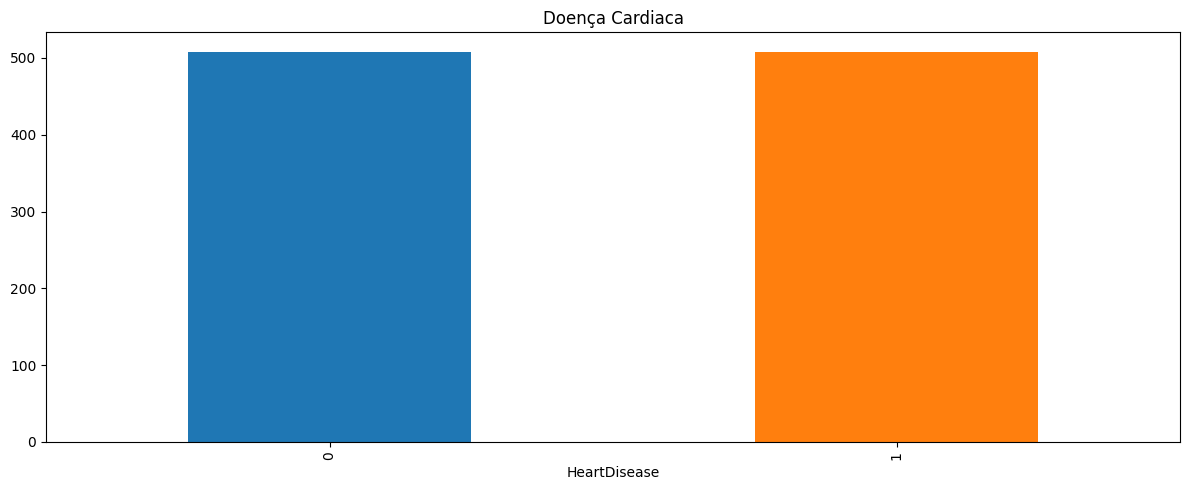

In [49]:
# Visualizando o balanceamento da variável TARGET
plt.rcParams["figure.figsize"] = [12.00, 5.00]
plt.rcParams["figure.autolayout"] = True
TARGET_RES.value_counts().plot(kind='bar', title='Doença Cardiaca',color = ['#1F77B4', '#FF7F0E']);

In [ ]:
# Visualizando a quantidade da variável target para balanceamento
variavel_target = TARGET_RES.value_counts()
variavel_target

#NOTE QUE: agora temos a mesma proporção de valores em ambos os grupos da variável target

HeartDisease
0    508
1    508
Name: count, dtype: int64

In [51]:
# Quantidade de registros antes do balanceamento
PREDITORAS.shape

(918, 11)

In [52]:
# Quantidade de registros antes do balanceamento
TARGET.shape

(918,)

In [ ]:
# Quantidade de registros após o balanceamento
PREDITORAS_RES.shape

(1016, 11)

In [ ]:
# Quantidade de registros após o balanceamento
TARGET_RES.shape

(1016,)

- Agora vamos dividir os dados em dados de treino e teste para iniciarmos a etapa de criação do modelo

In [55]:
# Divisão em Dados de Treino e Teste.
X_treino, X_teste, Y_treino, Y_teste = train_test_split(PREDITORAS_RES, TARGET_RES, test_size = 0.3, random_state = 42)

In [56]:
X_treino.shape

(711, 11)

- Note o problema abaixo que as escalas dos dados estão totalmente distinstas um das outras e isso também é um problema que precisamos   
tratar para ajudar no desenpenho do nosso modelo

In [57]:
X_treino.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope
177,59,1,1,140,287,0,1,150,0,0.00,2
467,63,0,1,132,0,0,1,130,0,0.10,2
507,40,1,2,106,240,0,1,80,1,0.00,2
486,55,1,1,110,214,1,2,180,0,0.40,2
328,52,1,0,95,0,1,1,82,1,0.80,1


- Com o **MinMaxScaler()** nós criamos uma escala de normalização dos nossos dados para que todos eles fiquem dentro de um padrão.   
Assim, resolvemos o problema de colunas com escalas distintas

In [58]:
# Normalização das Variáveis
Normalizador = MinMaxScaler()
X_treino_normalizados = Normalizador.fit_transform(X_treino)
X_teste_normalizados = Normalizador.transform(X_teste)

In [59]:
X_treino_normalizados.shape

(711, 11)

In [60]:
# Visualizando os dados NORMALIZADOS
X_treino_normalizados

array([[0.625     , 1.        , 0.33333333, ..., 0.        , 0.31707317,
        1.        ],
       [0.70833333, 0.        , 0.33333333, ..., 0.        , 0.32926829,
        1.        ],
       [0.22916667, 1.        , 0.66666667, ..., 1.        , 0.31707317,
        1.        ],
       ...,
       [0.64583333, 1.        , 0.        , ..., 1.        , 0.48780488,
        1.        ],
       [0.64583333, 1.        , 0.        , ..., 1.        , 0.31707317,
        1.        ],
       [0.22916667, 0.        , 0.        , ..., 0.        , 0.56097561,
        0.5       ]], shape=(711, 11))

In [61]:
X_teste_normalizados.shape

(305, 11)

In [62]:
X_teste_normalizados

array([[0.10416667, 0.        , 0.33333333, ..., 0.        , 0.40243902,
        1.        ],
       [0.70833333, 1.        , 0.        , ..., 1.        , 0.43902439,
        1.        ],
       [0.39583333, 1.        , 0.        , ..., 0.        , 0.31707317,
        0.5       ],
       ...,
       [0.625     , 1.        , 0.66666667, ..., 0.        , 0.51219512,
        1.        ],
       [0.58333333, 1.        , 0.33333333, ..., 0.        , 0.41463415,
        0.5       ],
       [0.39583333, 1.        , 0.66666667, ..., 0.        , 0.31707317,
        1.        ]], shape=(305, 11))

# Criando, Treinando e Avaliando os Modelos de Machine Learning

- Utilizando um dos hiperparâmetros presentes no modelo Random Forest

In [63]:
# Criando o classificador com Random Forest
clf = RandomForestClassifier(n_estimators  = 300, criterion = 'entropy', max_depth = 10, 
                             max_features = 'sqrt', min_samples_leaf = 2, min_samples_split = 2, n_jobs = 8)

# Construção do modelo
clf = clf.fit(X_treino_normalizados, Y_treino)

In [64]:
clf

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'entropy'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metri

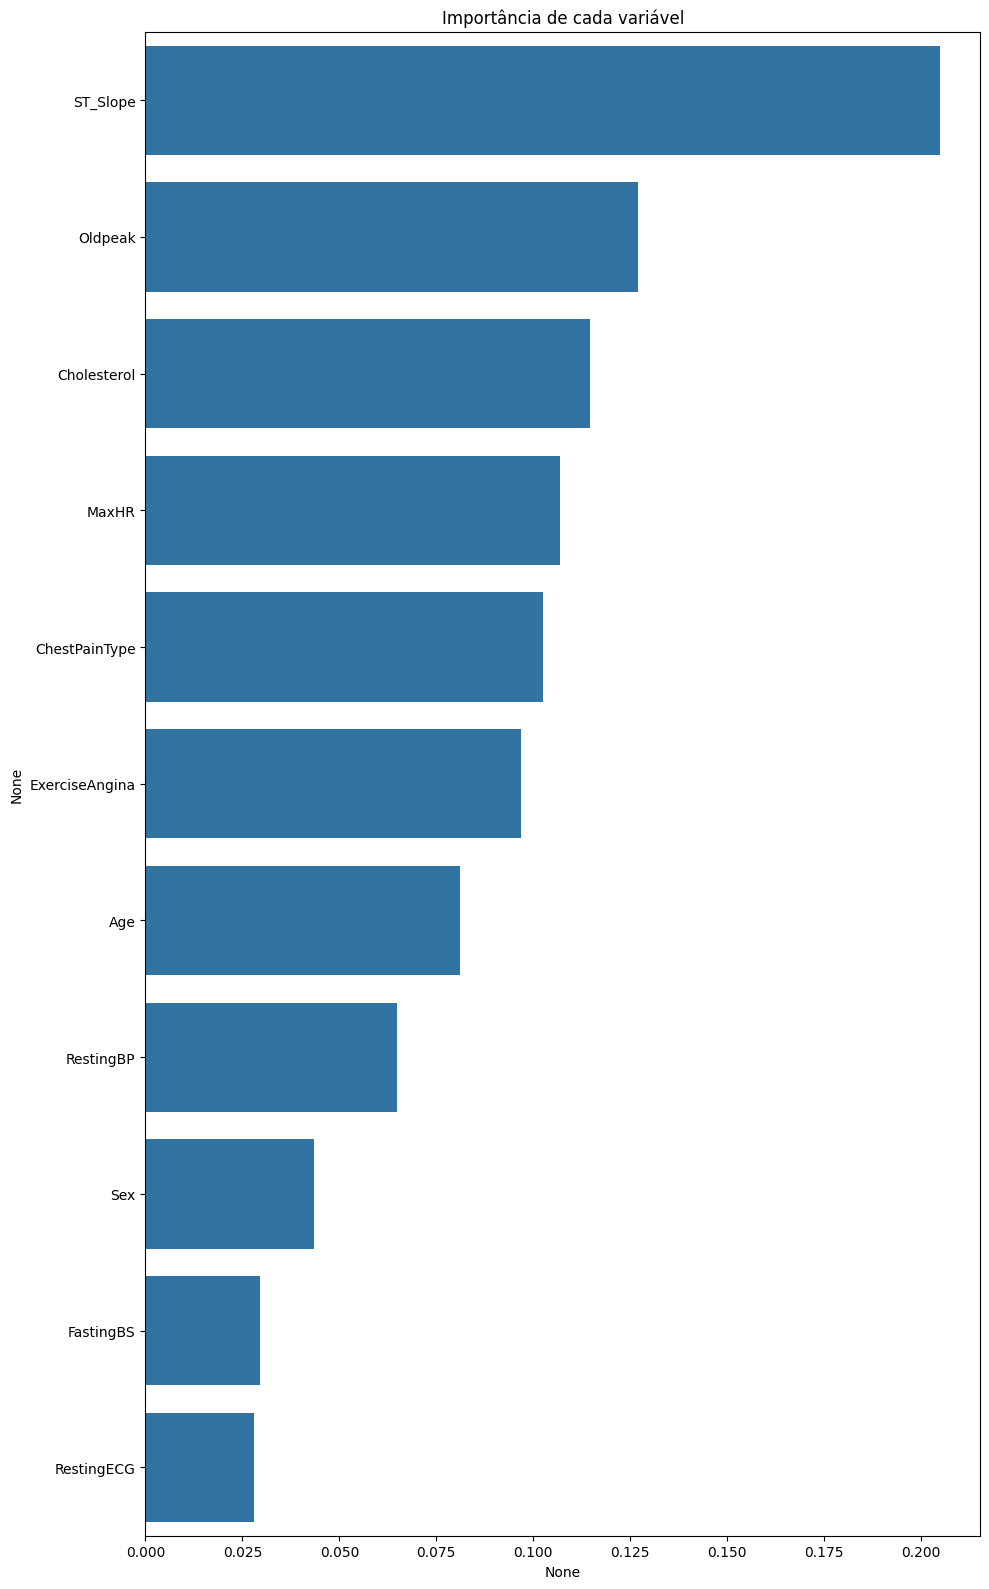

In [65]:
# Exibindo a importancia de cada variavel no modelo preditivo
plt.rcParams["figure.figsize"] = [10.00, 16.00]
plt.rcParams["figure.autolayout"] = True

importances = pd.Series(data=clf.feature_importances_, index=PREDITORAS.columns)
importances = importances.sort_values(ascending = False)
sns.barplot(x=importances, y=importances.index, orient='h').set_title('Importância de cada variável')
plt.show()

In [ ]:
# Visualizando o percentual de importância de cada variável
importances.sort_values(ascending = False)

ST_Slope         0.20
Oldpeak          0.13
Cholesterol      0.11
MaxHR            0.11
ChestPainType    0.10
ExerciseAngina   0.10
Age              0.08
RestingBP        0.06
Sex              0.04
FastingBS        0.03
RestingECG       0.03
dtype: float64

In [ ]:
# Estamos apenas "simulando" os dados de treino
scores = clf.score(X_treino_normalizados,Y_treino)
scores


#NOTE QUE: o nosso modelo atingiu 96% de acurácia nos dados de treino, esse número é bom pois não atingiu 100% que geralmente é
# um grande alerta de overfiting, ou seja, o modelo decorou os dados de treino e não consegue generalizar para novos dados.

0.9634317862165963

In [ ]:
# Estamos apenas "simulando" os dados de teste
scores = clf.score(X_teste_normalizados,Y_teste)
scores


#NOTE QUE: o nosso modelo nos testes atingiu 87% de acurácia, ter um resultado inferior ao de testes é normal, pois é aqui que o modelo
#executa na prática o que aprendeu nos dados de treino. 

0.8754098360655738

- O nosso modelo abaixo atingiu 87% de acurácia no teste. Mas o que isso significa? O que 87% representa para responder  
sobre o nosso modelo em relação a acertividade na descoberta de pacientes tendo ou nao problemas cardíacos???

- - Se o nosso modelo atingiu 96% no treino e 87% no teste, significa que ao se deparar com os novos dados durante o teste que foi  
aprendido durante o treino ele teve uma acertividade de 87% para poder dizer sobre quais pacientes tiveram doenças cardíacas ou não.  
Sendo assim, tivemos uma margem de erro de 13% na sua precisão.  
**O que sifnifica os erros e acertos? Nosso modelo acertou e errou sobre o que???**  
**Como podemos compreender melhor para ter uma resposta mais precisa sobre isso??**  
**O modelo acertou quando apontou sobre quem não tem problemas cardíacos ou sobre quem tem problemas cardíacos??**  
**O modelo apontou erradamente alguém como doente cardíaco sendo que ele nao era doente cardíacos???**

In [69]:
y_pred = clf.predict(X_teste_normalizados)
print(accuracy_score(Y_teste, y_pred)* 100)

87.54098360655738


- Todas as perguntas citadas acima são de extema importância para compreender as metricas sobre as respostas direcionadas do nosso modelo  
  
Por isso, podemos utilizar a **MATRIX CONFUSÃO (confusion_matrix)** para responder de forma mais clara sobre as perguntas citadas acima.
  
A **confusion_matrix** nos retorna sobre o que o modelo acertou e no que errou. Como queremos saber sobre a indicação de pacientes com  
ou sem possíveis problemas cardíacos precisamos saber o nível dee acerto nos **verdadeiros positivos, verdadeiros negativos, falsos positivos** **e falsos negativos**.  
**O QUE SIGNIFICA??**

- - **Verdadeiro positivo** = acertou quando apontou sobre quem poderá ter problema cardíaco  
**Verdadeiro negativo** = acertou quando apontou sobre quem não terá problema cardíaco  
**Falso positivo** = errou quando disse que um paciente poderá ter problema cardíaco mas na verdade não terá problema cardíaco  
**Falso negativo** = errou quando disse que um paciente não terá problema cardíaco mas na verdade ele terá sim um problema cardíaco  

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
print(confusion_matrix(Y_teste, y_pred))


#NOTE QUE: nosso modelo obteve as seguintes respostas em relação a matriz de confusão:

#VERDADEIRO POSITIVO = 119 acertividade sobre quem possa ter problema cardíaco
#VERDADEIRO NEGATIVO = 148 acertividade sobre quem não possa ter problema cardíaco
#FALSO POSITIVO = 19 erro ao dizer que poderá ter problema cardíaco quando na verdade não terá
#FALSO NEGATIVO = 19 erro ao dizer que não estará com problema cardíaco quando na verdade possa estar sim

[[119  19]
 [ 19 148]]


- Analisando os valores com **Classification_Report**. Mas afinal, como ler???

- - O C.R. contém métricas de avaliação que precisamos para enteder os resultados obtidos em nosso modelo.  
**Precision =** É a formula que calcula a precisão de acertos sobre os resultados verdadeiros. Ou seja, o número de acertos em relação  
quando o modelo diz quem estará doente e quem não estará doente.  
FORMULA= TP/ TP + FP  
  
- - **Recall =** É a formula que calcula sobre o erro quando o modelo erra em dizer que o paciente não estará doente mas na realidade ele estará  
doente sim. Ou seja, o número de acertos quando o modelo diz que estará doente de forma acertiva dividido pelo erro quando ele diz que o paciente não estará doente mas na realidade o paciente estará doente sim.  
FORMULA = TP/ TP + FN  
  
- - **F1-score =** É a formula que gera uma média harmonica entre o **Precision** e o **Recall**. Ou seja, é sobre tirar a média entre os acertos  
e erros do nosso modelo chegando em resultado médio entre os dois.  
FORMULA = 2/ [1/ Recall] + [1/ Precision]
  
--
- - SIGNIFICADO:  
- - TP = True Positive
- - TN = True Negative
- - FP = False Positive
- - FN = False Negative

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(Y_teste, y_pred))


#NOTE QUE: tivemos desempenhos próximos entre as métricas de avaliação abaixo

              precision    recall  f1-score   support

           0       0.86      0.86      0.86       138
           1       0.89      0.89      0.89       167

    accuracy                           0.88       305
   macro avg       0.87      0.87      0.87       305
weighted avg       0.88      0.88      0.88       305



In [72]:
cm = confusion_matrix(Y_teste, y_pred)

In [73]:
print(cm)

[[119  19]
 [ 19 148]]


In [74]:
cm_disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ["Sim","Não"])

- Visualizando a Matrix_Confusion em um gráfico plot

- - A lógica da leitura é a seguinte:  
TP(119) || FP(19)  
FN( 19) || TN(148)

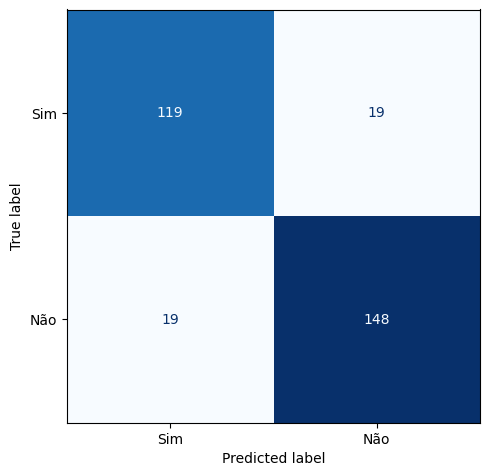

In [75]:
plt.rcParams["figure.figsize"] = [5.00, 5.00]
plt.rcParams["figure.autolayout"] = True
cm_disp.plot(include_values=True, 
             cmap='Blues',              
             colorbar=None)

- Visualizando a Matrix_Confusion em um gráfico no estilo Heatmap

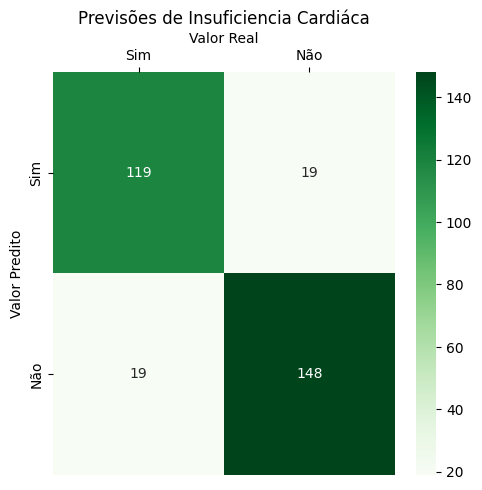

In [76]:
pd.options.display.float_format = '{:.2f}'.format

plt.rcParams["figure.figsize"] = [5.00, 5.00]
plt.rcParams["figure.autolayout"] = True

f, ax = plt.subplots(figsize=(5, 5))

sns.heatmap(cm, 
            cmap = "Greens", 
            annot = True,
            cbar_kws = {"orientation":"vertical"},            
            fmt=".0f",
            xticklabels = ["Sim","Não"],
            yticklabels = ["Sim","Não"])

ax.set_ylabel('Valor Predito')
ax.set_xlabel('Valor Real')

ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')

plt.title("Previsões de Insuficiencia Cardiáca")
plt.tick_params(axis='both', which='major', labelsize=10, labelbottom = False, bottom=False, top = True, labeltop=True)
plt.show()
